<a href="https://colab.research.google.com/github/Naveen-369/Kidney-Stone-Detection/blob/Production_Server/Multi_modal_fusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
akshayrajinikanth_us_kidney_data_path = kagglehub.dataset_download('akshayrajinikanth/us-kidney-data')
akshayrajinikanth_ct_scan_path = kagglehub.dataset_download('akshayrajinikanth/ct-scan')

print('Data source import complete.')


# Multi-modal fusion - Kidney stone prediction

Multimodal fusion is a powerful computational technique that integrates data from multiple modalities—such as text, images, audio, video, and sensor data—to create a unified representation for decision-making or prediction tasks. By combining diverse sources of information, multimodal fusion systems leverage the complementary strengths of each modality while mitigating their individual limitations. This approach is widely used in domains such as healthcare, natural language processing, computer vision, robotics, and multimedia analysis.

#### **What is Multimodal Fusion?**

Multimodal fusion refers to the process of synthesizing information from different types of data to improve the accuracy, robustness, and interpretability of machine learning models. Each modality provides unique insights into a problem:

- **Text**: Captures semantic meaning and context.

- **Images**: Provide spatial and visual information.

- **Audio**: Conveys tonal and emotional cues.

- **Sensor Data**: Offers real-time environmental or physiological measurements.

For example, in human activity recognition, multimodal fusion might combine video footage with accelerometer data to achieve higher accuracy than either modality alone.

#### **How Multimodal Fusion Works?**
Multimodal fusion involves three primary stages:

- **Feature Extraction**: Extract meaningful features from each modality using specialized techniques (e.g., convolutional neural networks for images, transformers for text).

- **Fusion Mechanism**: Combine features or predictions from different modalities using one of the following strategies:

- **Early Fusion**: Merge raw or preprocessed data before feature extraction.

- **Late Fusion**: Combine outputs from separate models trained on individual modalities.

- **Hybrid Fusion**: Dynamically adjust fusion mechanisms based on data quality or availability.

- **Decision Making**: Use the fused representation for classification, regression, or other predictive tasks.

#### Representation of Multimodal fusion
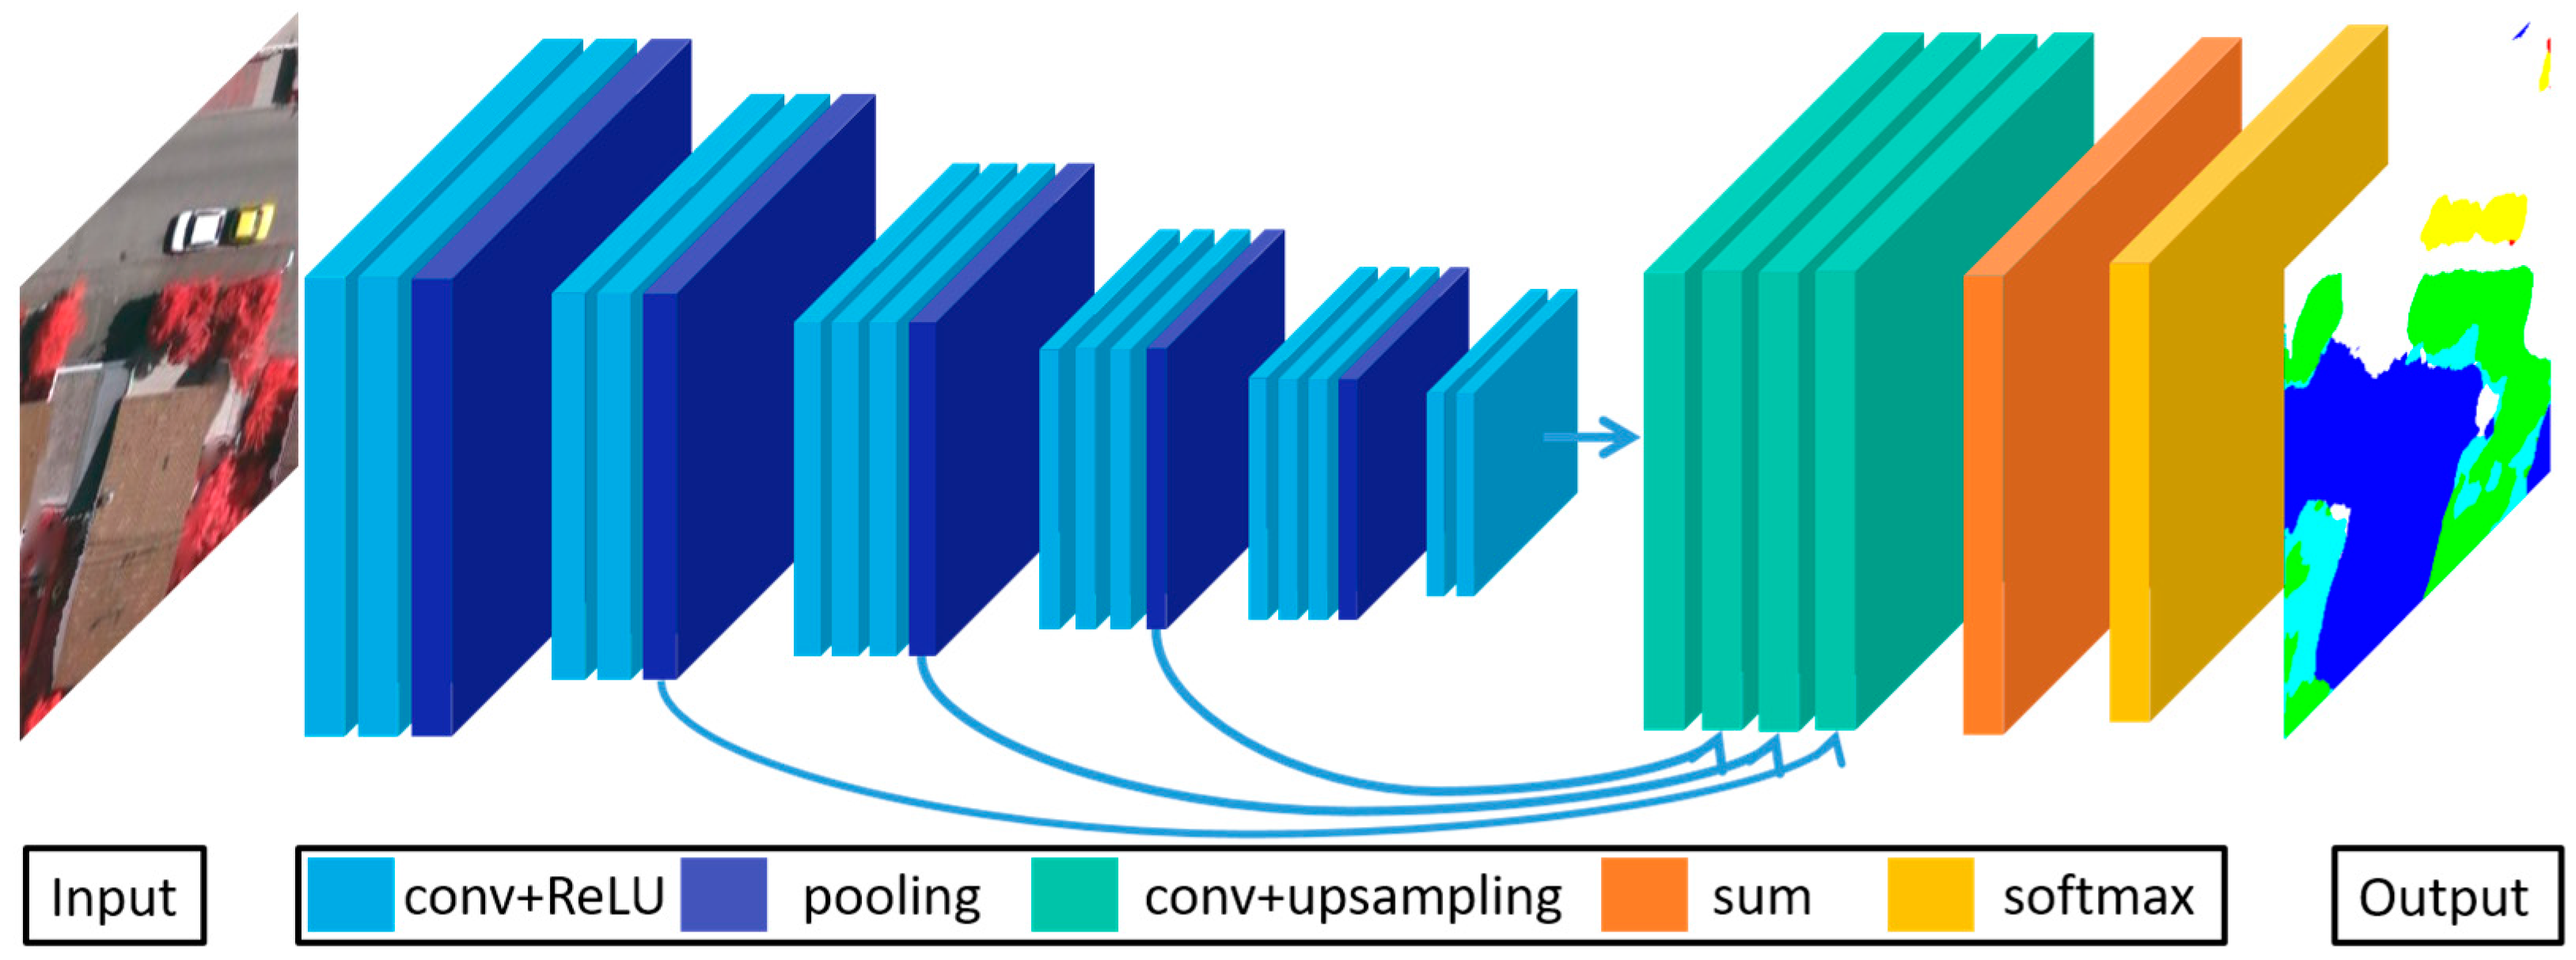

#### Advantages of Multimodal Fusion
- **Improved Accuracy**: Leveraging complementary information reduces errors and increases reliability.

- **Robustness**: Systems can handle noisy or incomplete data by prioritizing high-confidence modalities.

- **Contextual Understanding**: Captures richer insights by combining spatial, temporal, and semantic information.

## Data Manipulation

### Source of ultra sound data:
**Description of the Dataset**: Kidney Ultrasound Images "Stone" and "No Stone"
This dataset, published on August 27, 2024, provides a comprehensive collection of kidney ultrasound images aimed at supporting research in the epidemiology and diagnosis of kidney stones. It is curated by Dr. Sukhwinder Singh and hosted by Punjabi University Bhai Kahn Singh Nabha Library.

#### Key Features
Total Images: The dataset contains 9,416 ultrasound images, divided into two categories:

**Normal (No Stone)**: 4,414 images.

**Stone**: 5,002 images.

**Data Collection**: The images were sourced from various scan centers and hospitals, ensuring patient privacy and confidentiality throughout the process.

**Ultrasound Machines Used**: The dataset includes images captured using multiple ultrasound machines, ensuring diversity in image quality and settings:

- SAMSUNG RS85

- SAMSUNG HS60

- SAMSUNG RS80A

- SAMSUNG HS70A

#### Applications
This dataset is particularly useful for:

- Developing machine learning models for kidney stone detection.

- Studying the epidemiology of kidney stones.

- Benchmarking algorithms for medical image classification.

#### Institution
- The dataset is maintained by Punjabi University Bhai Kahn Singh Nabha Library, underscoring its academic contribution to nephrology research.

- This resource provides a valuable foundation for advancing diagnostic techniques and understanding kidney stone prevalence through data-driven approaches.

**Link** - https://data.mendeley.com/datasets/h6jc4xm4py/1

### Source of CT scan data:
**Description of the Dataset**:
This dataset, published on February 18, 2025, provides a comprehensive collection of axial CT scan images specifically curated for kidney stone detection. It has been meticulously verified and labeled by experienced medical professionals, making it a high-quality resource for research, algorithm development, and educational purposes.

#### Key Features
##### Dataset Composition:

**Original CT Images**: 3,364 images.

**Augmented CT Images**: 35,457 images (generated to enhance dataset diversity and applicability).

#### Data Categories:

CT scans from individuals diagnosed with kidney stones.

CT scans from individuals without kidney stones.

#### Source:

Collected from medical centers in Sulaimani and Rania, Kurdistan Region, Iraq.

Provides unique insights into the prevalence and characteristics of kidney stones in this region.

#### Curation:

The dataset has been labeled and verified by medical experts to ensure reliability and accuracy.

#### Applications
This dataset is valuable for:

- Training and evaluating deep learning models for kidney stone detection.

- Advancing diagnostic tools using artificial intelligence.

- Supporting medical research on kidney stone prevalence and characteristics.

- Serving as an educational resource for students and researchers studying medical imaging.

#### Significance
The inclusion of augmented images significantly enhances the dataset's utility by increasing its size and variability, making it suitable for robust algorithm training. This dataset can play a pivotal role in improving diagnostic accuracy, reducing false positives or negatives, and advancing AI-powered solutions in healthcare.

### Stratified Medical Image Dataset Split
This code performs a structured partitioning of kidney ultrasound images into training (70%), validation (15%), and test (15%) sets while preserving class balance ("Stone" vs. "No Stone"). Key features include:

1. **Directory Preservation**: Maintains original class-specific folder structures to simplify integration with frameworks like PyTorch's ImageFolder or TensorFlow's ImageDataGenerator.

2. **Randomized Stratification**: Uses sklearn.model_selection.train_test_split with a fixed random seed (random_state=42) to ensure reproducibility and prevent data leakage.

3. **Multi-Machine Compatibility**: Handles images from diverse ultrasound machines (SAMSUNG RS85, HS60, etc.) uniformly, ensuring balanced representation across splits.

4. **Patient Privacy**: Copies images without modification to preserve anonymization and original metadata.

**Purpose**: Creates standardized splits for training/evaluating multimodal fusion models while mitigating bias from uneven modality distributions.

#### CT scan data

In [ ]:
import os
import shutil
import random
from sklearn.model_selection import train_test_split

# Define dataset paths
DATASET_PATH = "/kaggle/input/ct-scan/my dataset final 512x512(implemented)"  # Update with your dataset path
OUTPUT_DIR = "split_dataset"  # Output directory for train, test, val
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15  # 15% validation, 15% test

# Create output directories
for split in ["train", "val", "test"]:
    split_path = os.path.join(OUTPUT_DIR, split)
    os.makedirs(split_path, exist_ok=True)

# Get class names (folder names)
classes = os.listdir(DATASET_PATH)

for class_name in classes:
    class_path = os.path.join(DATASET_PATH, class_name)
    images = os.listdir(class_path)

    # Shuffle and split dataset
    train_imgs, test_imgs = train_test_split(images, test_size=(1 - TRAIN_RATIO), random_state=42)
    val_imgs, test_imgs = train_test_split(test_imgs, test_size=0.5, random_state=42)

    # Copy images to train, val, and test folders
    for split, imgs in zip(["train", "val", "test"], [train_imgs, val_imgs, test_imgs]):
        split_class_dir = os.path.join(OUTPUT_DIR, split, class_name)
        os.makedirs(split_class_dir, exist_ok=True)

        for img in imgs:
            shutil.copy(os.path.join(class_path, img), os.path.join(split_class_dir, img))

print("Dataset successfully split into train, validation, and test sets!")

Dataset successfully split into train, validation, and test sets!


#### Ultra-sound data

In [ ]:
original_dataset_path = "/kaggle/input/us-kidney-data/kidney US images/my dataset final 512x512(implemented)"
output_path = "/kaggle/working/split_dataset1"

categories = ["Normal", "stone"]  # Adjust if your folder names are different (case-sensitive)
splits = ["train", "val", "test"]
train_ratio, val_ratio, test_ratio = 0.6, 0.15, 0.25

IMG_SIZE = (512, 512)
BATCH_SIZE = 16
EPOCHS = 30
SEED = 42
random.seed(SEED)

# Create split directories
for split in splits:
    for category in categories:
        os.makedirs(os.path.join(output_path, split, category), exist_ok=True)

def split_data(category):
    category_path = os.path.join(original_dataset_path, category)
    if not os.path.exists(category_path):
        print(f"ERROR: {category_path} does not exist!")
        return
    images = [f for f in os.listdir(category_path) if os.path.isfile(os.path.join(category_path, f))]
    if len(images) == 0:
        print(f"WARNING: No images found in {category_path}")
        return
    random.shuffle(images)
    train_split = int(len(images) * train_ratio)
    val_split = int(len(images) * (train_ratio + val_ratio))
    train_images = images[:train_split]
    val_images = images[train_split:val_split]
    test_images = images[val_split:]
    for img in train_images:
        shutil.copy(os.path.join(category_path, img), os.path.join(output_path, "train", category, img))
    for img in val_images:
        shutil.copy(os.path.join(category_path, img), os.path.join(output_path, "val", category, img))
    for img in test_images:
        shutil.copy(os.path.join(category_path, img), os.path.join(output_path, "test", category, img))

for category in categories:
    split_data(category)

def check_class_balance(base_path):
    for split in splits:
        print(f"\n{split.upper()} SET:")
        total = 0
        split_counts = {}
        for category in categories:
            dir_path = os.path.join(base_path, split, category)
            count = len([f for f in os.listdir(dir_path) if os.path.isfile(os.path.join(dir_path, f))])
            split_counts[category] = count
            total += count
            print(f"  - {category}: {count} images")
        if total > 0:
            for category in categories:
                print(f"  - {category} percentage: {split_counts[category]/total*100:.1f}%")
check_class_balance(output_path)


TRAIN SET:
  - Normal: 2648 images
  - stone: 3001 images
  - Normal percentage: 46.9%
  - stone percentage: 53.1%

VAL SET:
  - Normal: 662 images
  - stone: 750 images
  - Normal percentage: 46.9%
  - stone percentage: 53.1%

TEST SET:
  - Normal: 1104 images
  - stone: 1251 images
  - Normal percentage: 46.9%
  - stone percentage: 53.1%


### Image Augmentation
#### Description
This code implements a data loading and augmentation pipeline optimized for kidney scan image analysis, designed to enhance model generalization while maintaining diagnostic integrity.

#### Key Features:
1. **Augmentation Strategy**:

- Training Data: Applies rotation (±30°), zoom (20% scale variation), and horizontal flipping to simulate clinical variations in ultrasound imaging (e.g., probe positioning, patient anatomy).

- Validation/Test Data: Uses only rescaling (1/255) to preserve original image characteristics for reliable evaluation.

2. **Preprocessing**:

- Standardizes images to 512×512 resolution, aligning with common CNN architectures (e.g., ResNet, Inception).

- Normalizes pixel values to range for stable gradient computation.

2. **Batch Generation**:

- Uses 16-image batches to balance GPU memory usage and gradient estimation accuracy.

- Preserves test set order (shuffle=False) for precise performance metrics and error analysis.

4. **Class Handling**:

- Automatically detects classes ("Stone"/"No Stone") from directory structure.

- Outputs categorical labels for compatibility with softmax-based classification.

#### Image augmentation of CT scan

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (512, 512)
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=30, zoom_range=0.2, horizontal_flip=True)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    directory=os.path.join(OUTPUT_DIR, "train"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_generator = val_datagen.flow_from_directory(
    directory=os.path.join(OUTPUT_DIR, "val"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_generator = val_datagen.flow_from_directory(
    directory=os.path.join(OUTPUT_DIR, "test"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("Dataset loaded successfully!")

2025-05-21 03:20:36.355822: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747797636.551032      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747797636.607421      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Found 6590 images belonging to 2 classes.
Found 1412 images belonging to 2 classes.
Found 1414 images belonging to 2 classes.
Dataset loaded successfully!


#### Image augmentation of Ultrasound scan

In [ ]:

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True
)
val_gen = ImageDataGenerator(rescale=1./255)

train_ds = train_gen.flow_from_directory(
    directory=os.path.join(output_path, "train"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)
val_ds = val_gen.flow_from_directory(
    directory=os.path.join(output_path, "val"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)
test_ds = val_gen.flow_from_directory(
    directory=os.path.join(output_path, "test"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 5649 images belonging to 2 classes.
Found 1412 images belonging to 2 classes.
Found 2355 images belonging to 2 classes.


## Model Development

### Kidney stone prediction using CT scan: InceptionV3

Inception-v3 is a convolutional neural network (CNN) architecture introduced in the paper "*Rethinking the Inception Architecture for Computer Vision*" by Christian Szegedy et al. It is part of the Inception family and represents significant improvements in efficiency and accuracy compared to earlier versions, such as GoogLeNet (Inception-v1). The architecture was designed to scale up convolutional networks while reducing computational costs, making it suitable for large-scale image classification tasks.


#### Key Features
1. **Factorized Convolutions**: Traditional large convolutions (e.g., 7×7) are factorized into smaller operations, such as three consecutive 3×3 convolutions. This reduces computational cost while maintaining the same receptive field size.

2. **Inception Modules**: The building blocks of the network are modular components known as Inception modules. These modules use parallel paths with different filter sizes (e.g., 1×1, 3×3, pooling) to capture multi-scale features efficiently.

3. **Grid Reduction Techniques**: Grid sizes are reduced between layers using specialized techniques, allowing deeper networks without excessive computational overhead.

4. **Auxiliary Classifier**: An auxiliary classifier is added to intermediate layers during training to propagate label information and improve gradient flow.

5. **Regularization Techniques**: Incorporates methods like Batch Normalization and Label Smoothing to prevent overfitting and improve generalization.

6. **Pretrained Model Availability**: Pretrained weights on ImageNet are available for transfer learning, achieving top-1 accuracy of 77.45% and top-5 accuracy of 93.56% on ImageNet.

#### Architecture Overview
The network processes input images of size 299×299×3 through several convolutional layers followed by Inception modules:

1. **Initial Layers**: Convolutions and pooling operations reduce the input size to 35×35×192.

2. **Inception Modules**:

   - Three modules with 35×35×288 filters.

   - Five modules with 17×17×768 filters.

   - Two modules with 8×8×1280 filters.

3. **Final Layers**:

   - Global average pooling reduces the feature map size to 8×8×2048.

   - Fully connected layer outputs logits for classification tasks.
  
4. **visual representation**:

   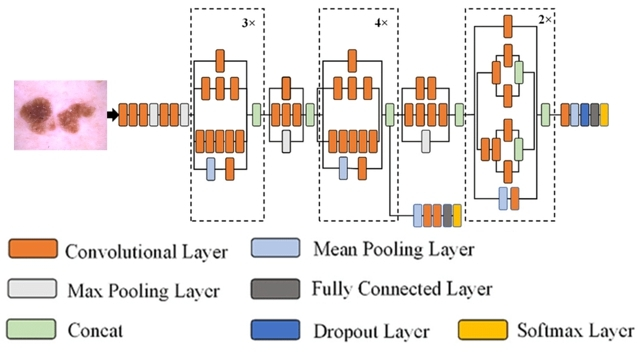
#### Advantages
1. **Computational Efficiency**:

   - Uses fewer parameters compared to monolithic architectures like VGGNet, while achieving higher accuracy.

2. **Scalability**:

   - Modular design enables easy scaling for larger datasets or more complex tasks.

3. **Versatility**:

   - Applicable across a wide range of computer vision tasks, including image classification, object detection, and adversarial robustness.

#### Applications
- Large-scale image classification (e.g., ImageNet).

- Transfer learning for domain-specific tasks like medical imaging or autonomous vehicles.

- Object detection and segmentation when combined with additional layers or frameworks.

#### Significance
Inception-v3 set a new benchmark in computer vision by balancing performance and computational cost. Its innovative design principles—such as factorized convolutions, auxiliary classifiers, and grid reduction—continue to influence modern architectures in deep learning research.

- **Importing necessary library:**

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

- **Building a model:**

In [ ]:
NUM_CLASSES = len(classes)

# Load InceptionV3 without top layers
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(512, 512, 3))
base_model.trainable = False  # Freeze initial layers

# Custom classification head
x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.4)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.2)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

# Compile the model
model_ct = Model(inputs=base_model.input, outputs=output)
model_ct.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

I0000 00:00:1747797672.173265      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1747797672.173887      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


- **Training the model:**

In [ ]:
EPOCHS = 10  # Start with a small number and increase if needed

history = model_ct.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1747797701.482989     137 service.cc:148] XLA service 0x7c7e0c45afe0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747797701.483789     137 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1747797701.483810     137 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1747797703.432267     137 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1747797716.400892     137 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of th

412/412 ━━━━━━━━━━━━━━━━━━━━ 417s 935ms/step - accuracy: 0.8353 - loss: 0.3703 - val_accuracy: 0.9851 - val_loss: 0.0885
Epoch 2/10
412/412 ━━━━━━━━━━━━━━━━━━━━ 368s 878ms/step - accuracy: 0.9482 - loss: 0.1470 - val_accuracy: 0.9858 - val_loss: 0.0504
Epoch 3/10
412/412 ━━━━━━━━━━━━━━━━━━━━ 360s 859ms/step - accuracy: 0.9609 - loss: 0.1109 - val_accuracy: 0.9830 - val_loss: 0.0686
Epoch 4/10
412/412 ━━━━━━━━━━━━━━━━━━━━ 359s 858ms/step - accuracy: 0.9624 - loss: 0.0998 - val_accuracy: 0.9865 - val_loss: 0.0442
Epoch 5/10
412/412 ━━━━━━━━━━━━━━━━━━━━ 358s 855ms/step - accuracy: 0.9663 - loss: 0.0966 - val_accuracy: 0.9837 - val_loss: 0.0661
Epoch 6/10
412/412 ━━━━━━━━━━━━━━━━━━━━ 358s 855ms/step - accuracy: 0.9677 - loss: 0.0928 - val_accuracy: 0.9929 - val_loss: 0.0256
Epoch 7/10
412/412 ━━━━━━━━━━━━━━━━━━━━ 358s 854ms/step - accuracy: 0.9684 - loss: 0.0920 - val_accuracy: 0.9837 - val_loss: 0.0569
Epoch 8/10
412/412 ━━━━━━━━━━━━━━━━━━━━ 358s 855ms/step - accuracy: 0.9751 - loss: 0.06

- **Testing the accuracy of the model:**

In [ ]:
# Evaluate on test set
test_loss, test_acc = model_ct.evaluate(test_generator)
print(f'Test Accuracy: {test_acc * 100:.2f}%')

89/89 ━━━━━━━━━━━━━━━━━━━━ 25s 276ms/step - accuracy: 0.9752 - loss: 0.0640
Test Accuracy: 98.51%


- **F1 score of the model:**

89/89 ━━━━━━━━━━━━━━━━━━━━ 17s 191ms/step

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.98       663
       stone       0.98      1.00      0.99       751

    accuracy                           0.99      1414
   macro avg       0.99      0.98      0.99      1414
weighted avg       0.99      0.99      0.99      1414


 Confusion Matrix : 
[[644  19]
 [  2 749]]

	 Visualization : 


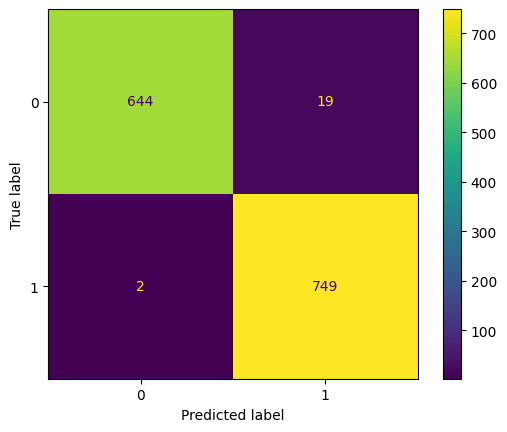

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

test_generator.reset()
y_pred = model_ct.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes


print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=categories))
print("\n Confusion Matrix : ")
print(confusion_matrix(y_true, y_pred_classes))
print("\n\t Visualization : ")
ConfusionMatrixDisplay.from_predictions(y_true,y_pred_classes)

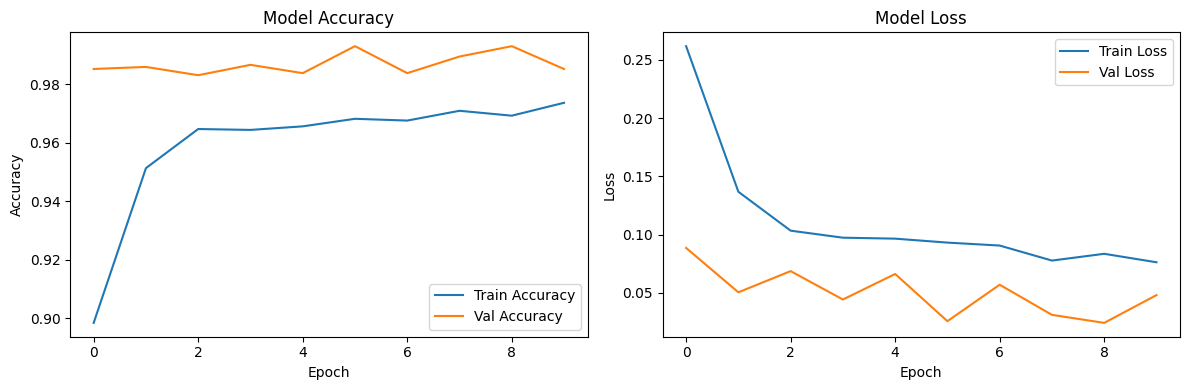

In [ ]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import classification_report, f1_score
import numpy as np

y_true = []
y_pred = []

for x_batch, y_batch in test_generator:
    preds = model_ct.predict(x_batch)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(y_batch, axis=1))

    if len(y_true) >= test_generator.samples:
        break

# F1 Score Calculation
f1 = f1_score(y_true, y_pred, average='weighted')
print(f"Weighted F1 Score: {f1:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=test_generator.class_indices.keys()))


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━

### Kidney stone prediction using ultrasound scan: Hybrid CNN-LSTM
The hybrid CNN-LSTM architecture combines the strengths of Convolutional Neural Networks (CNNs) and Long Short-Term Memory (LSTM) networks to process both spatial and sequential data, achieving superior performance across diverse domains. Below is a detailed breakdown of its design, mechanisms, and applications based on recent research.



#### Key features
##### 1. Convolutional Neural Network (CNN) Backbone:
- Purpose: Extracts hierarchical spatial features from input images.

   - Conv2D Layers: Detect edges, textures, and patterns in ultrasound images using 3×3 filters.

   - MaxPooling: Reduces spatial dimensions (512×512 → 64×64) while retaining critical features.

- Why It Matters: CNNs excel at capturing local structures (e.g., kidney boundaries, stone shapes).

##### 2. Reshaping for LSTM Compatibility:
- Flatten: Converts 3D feature maps (e.g., 64×64×128) into 1D vectors (524,288 features).

- Reshape: Transforms flattened data into a sequence format (timesteps, features) for LSTM:

   - `-1`: Automatically infers the number of timesteps (e.g., 4,096 steps for 524,288/128).

   - `128`: Features per timestep, mimicking a "pseudo-time series" from spatial data.

##### 3. Long Short-Term Memory (LSTM) Layer:
- **Purpose**: Analyzes sequential relationships between spatial regions of the image.

- **Mechanism**:

   - Processes the reshaped sequence to model dependencies (e.g., how kidney regions correlate).

   - **64 Units**: Hidden state size, balancing complexity and computational cost.

- **Clinical Relevance**: Can capture contextual patterns (e.g., stone distribution across slices).

##### 4. Classification Head:
   - First Dense(64): Non-linear transformation of LSTM outputs.

   - Final Dense(2): Outputs probabilities for "Stone" vs. "No Stone" using softmax.

#### Key Design Considerations
1. **Input Size**: Optimized for 512×512 medical images (common resolution in ultrasound/CT).

2. **Why LSTM?**: While unconventional for pure images, it may model spatial context as sequences (e.g., scanning kidney regions systematically).

#### Trade-offs:

1. **Pros**: Combines CNN’s spatial acuity with LSTM’s contextual reasoning.

2. **Cons**: High computational cost due to flattening 512x512 images.

1. **Building a model:**

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

input_shape = (512, 512, 3)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
base_model.trainable = False

inputs = Input(shape=input_shape)
x = base_model(inputs)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.2)(x)
outputs = Dense(2, activation='softmax')(x)
model_us = Model(inputs=inputs, outputs=outputs)

model_us.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_us.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 512, 512, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ vgg16 (Functional)                   │ (None, 16, 16, 512)         │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 2)                   │             514 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,846,530 (56.64 MB)

 Trainable params: 131,842 (515.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

2.**Training the model:**

In [ ]:
# Train the model
EPOCHS = 3
history_us = model_us.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)


Epoch 1/3
354/354 ━━━━━━━━━━━━━━━━━━━━ 348s 965ms/step - accuracy: 0.8561 - loss: 0.3627 - val_accuracy: 0.9788 - val_loss: 0.1905
Epoch 2/3
354/354 ━━━━━━━━━━━━━━━━━━━━ 349s 968ms/step - accuracy: 0.8660 - loss: 0.3331 - val_accuracy: 0.9851 - val_loss: 0.1606
Epoch 3/3
354/354 ━━━━━━━━━━━━━━━━━━━━ 349s 967ms/step - accuracy: 0.8714 - loss: 0.3124 - val_accuracy: 0.9688 - val_loss: 0.1645


3.**Testing the model:**

In [ ]:
# Evaluate on test data
test_loss, test_acc = model_us.evaluate(test_ds)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

148/148 ━━━━━━━━━━━━━━━━━━━━ 73s 494ms/step - accuracy: 0.9550 - loss: 0.2283
Test Accuracy: 97.07%


148/148 ━━━━━━━━━━━━━━━━━━━━ 74s 499ms/step

Confusion Matrix:
[[1037   67]
 [   2 1249]]

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.94      0.97      1104
       stone       0.95      1.00      0.97      1251

    accuracy                           0.97      2355
   macro avg       0.97      0.97      0.97      2355
weighted avg       0.97      0.97      0.97      2355


	 Confusion matrix visualization : 


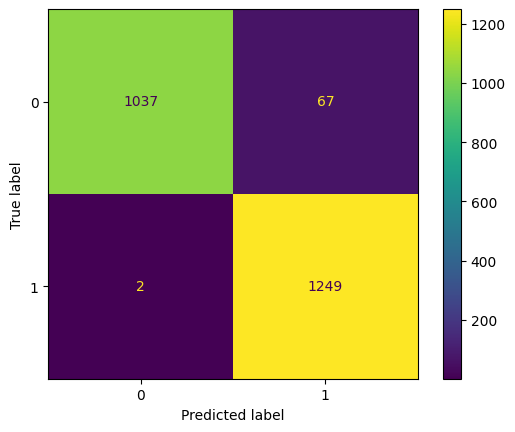

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

test_ds.reset()
y_pred = model_us.predict(test_ds)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_ds.classes

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred_classes))
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=categories))
print("\n\t Confusion matrix visualization : ")
ConfusionMatrixDisplay.from_predictions(y_true,y_pred_classes)

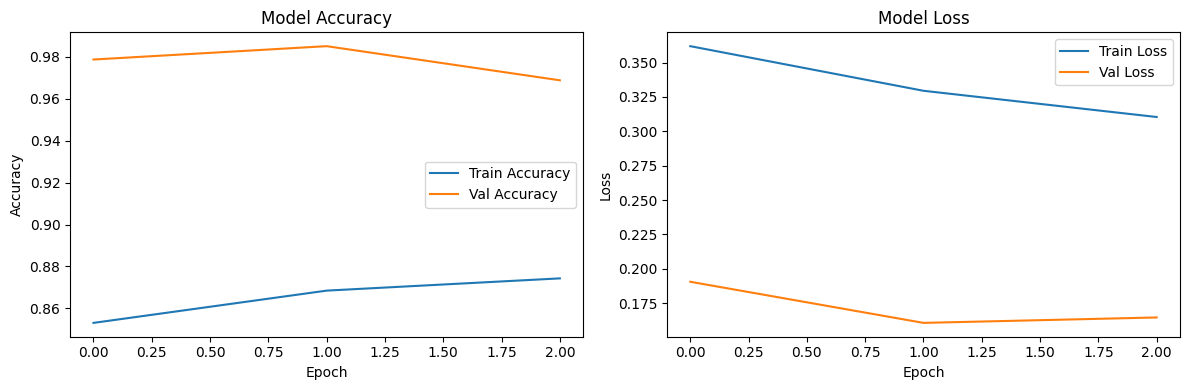

In [ ]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_us.history['accuracy'], label='Train Accuracy')
plt.plot(history_us.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history_us.history['loss'], label='Train Loss')
plt.plot(history_us.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


## Modal fusion

In [ ]:
from tensorflow.keras.applications import InceptionV3, VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D, Concatenate
from tensorflow.keras.optimizers import Adam

input_shape = (512, 512, 3)
NUM_CLASSES = len(classes)

# ----- CT branch (InceptionV3) -----
ct_input = Input(shape=input_shape, name="ct_input")
ct_base = InceptionV3(weights='imagenet', include_top=False, input_shape=input_shape)
ct_base.trainable = False
ct_features = ct_base(ct_input)
ct_features = GlobalAveragePooling2D()(ct_features)         # shape: (None, 2048)
ct_features = Dense(512, activation='relu')(ct_features)    # project to same dim

# ----- US branch (VGG16) -----
us_input = Input(shape=input_shape, name="us_input")
us_base = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
us_base.trainable = False
us_features = us_base(us_input)
us_features = GlobalAveragePooling2D()(us_features)         # shape: (None, 512)
us_features = Dense(512, activation='relu')(us_features)    # project to same dim

# ----- Fusion -----
merged = Concatenate()([ct_features, us_features])          # shape: (None, 1024)
merged = Dropout(0.5)(merged)
merged = Dense(256, activation='relu')(merged)
merged = Dropout(0.3)(merged)
output = Dense(NUM_CLASSES, activation='softmax')(merged)

fusion_model = Model(inputs=[ct_input, us_input], outputs=output)
fusion_model.compile(optimizer=Adam(learning_rate=0.0001),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

fusion_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ ct_input (InputLayer)     │ (None, 512, 512, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ us_input (InputLayer)     │ (None, 512, 512, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ inception_v3 (Functional) │ (None, 14, 14, 2048)   │     21,802,784 │ ct_input[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ vgg16 (Functional)        │ (None, 16, 16, 512)    │     14,714,688 │ us_input[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d… │ (None, 2048)           │              0 │ inception_v3[0][0]     │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d… │ (None, 512)            │              0 │ vgg16[0][0]            │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_8 (Dense)           │ (None, 512)            │      1,049,088 │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_9 (Dense)           │ (None, 512)            │        262,656 │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_7             │ (None, 1024)           │              0 │ dense_8[0][0],         │
│ (Concatenate)             │                        │                │ dense_9[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_6 (Dropout)       │ (None, 1024)           │              0 │ concatenate_7[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_10 (Dense)          │ (None, 256)            │        262,400 │ dropout_6[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_7 (Dropout)       │ (None, 256)            │              0 │ dense_10[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_11 (Dense)          │ (None, 2)              │            514 │ dropout_7[0][0]        │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 38,092,130 (145.31 MB)

 Trainable params: 1,574,658 (6.01 MB)

 Non-trainable params: 36,517,472 (139.30 MB)

In [ ]:
def create_tf_dataset(ct_gen, us_gen):
    def generator():
        for i in range(min(len(ct_gen), len(us_gen))):
            ct_imgs, labels_ct = ct_gen[i]
            us_imgs, labels_us = us_gen[i]

            # Check if batch sizes match
            if ct_imgs.shape[0] != us_imgs.shape[0]:
                continue  # skip mismatched batch

            yield ((ct_imgs, us_imgs), labels_ct)

    output_signature = (
        (
            tf.TensorSpec(shape=(None, 512, 512, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(None, 512, 512, 3), dtype=tf.float32)
        ),
        tf.TensorSpec(shape=(None, NUM_CLASSES), dtype=tf.float32)
    )

    return tf.data.Dataset.from_generator(generator, output_signature=output_signature)



In [ ]:
train_fusion_ds = create_tf_dataset(train_generator, train_ds)
val_fusion_ds = create_tf_dataset(val_generator, val_ds)
test_fusion_ds = create_tf_dataset(test_generator, test_ds)

In [ ]:
history = fusion_model.fit(
    train_fusion_ds,
    validation_data=val_fusion_ds,
    epochs=4,
    steps_per_epoch=min(len(train_generator), len(train_ds)),
    validation_steps=min(len(val_generator), len(val_ds)),    # This step should be reconsidered
)

Epoch 1/4
353/354 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step - accuracy: 0.7847 - loss: 0.4190

/usr/lib/python3.11/contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


354/354 ━━━━━━━━━━━━━━━━━━━━ 686s 2s/step - accuracy: 0.7849 - loss: 0.4186 - val_accuracy: 0.9816 - val_loss: 0.0627
Epoch 2/4
354/354 ━━━━━━━━━━━━━━━━━━━━ 582s 2s/step - accuracy: 0.9532 - loss: 0.1288
Epoch 3/4
354/354 ━━━━━━━━━━━━━━━━━━━━ 665s 2s/step - accuracy: 0.9654 - loss: 0.0893 - val_accuracy: 0.9681 - val_loss: 0.1056
Epoch 4/4
354/354 ━━━━━━━━━━━━━━━━━━━━ 590s 2s/step - accuracy: 0.9704 - loss: 0.0863


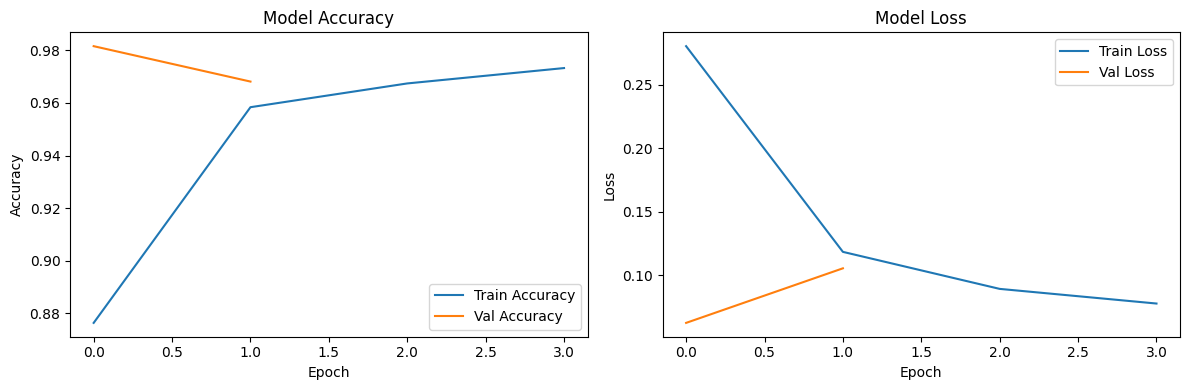

In [ ]:
import matplotlib.pyplot as plt

# Accuracy graph of the fused model
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss of the Fused Model
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()
# Dont include the following image in draft

In [ ]:
loss, accuracy = fusion_model.evaluate(test_fusion_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

88/88 ━━━━━━━━━━━━━━━━━━━━ 62s 700ms/step - accuracy: 0.9657 - loss: 0.0961
Test Loss: 0.0598
Test Accuracy: 0.9808


In [ ]:
from sklearn.metrics import classification_report, f1_score
import numpy as np

# Get predictions and true labels
y_true = []
y_pred = []

for (ct_batch, us_batch), labels in test_fusion_ds:
    preds = fusion_model.predict((ct_batch, us_batch))
    y_true.extend(np.argmax(labels, axis=1))       # one-hot → label index
    y_pred.extend(np.argmax(preds, axis=1))         # softmax → label index

# Compute F1 Score
f1 = f1_score(y_true, y_pred, average='weighted')  # use 'macro' or 'micro' as needed
print(f"F1 Score (weighted): {f1:.4f}")

# Optional: Print full classification report
print(classification_report(y_true, y_pred, target_names=classes))

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 


	 Confusion matrix visualization : 


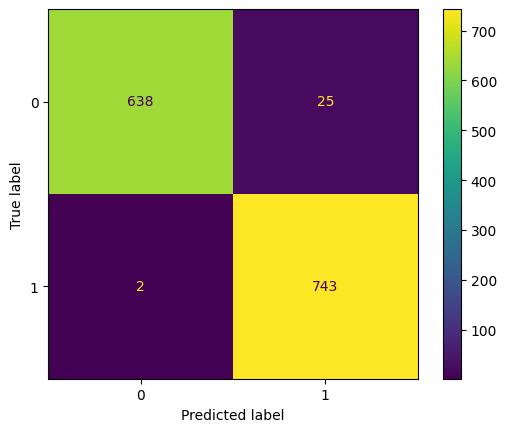

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

print("\n\t Confusion matrix visualization : ")
ConfusionMatrixDisplay.from_predictions(y_true,y_pred)

## Saving the Modal


In [ ]:
fusion_model.save("Multi_Modal_Fusion_for_Kidney_Stone_Detection.keras")
fusion_model.save("Multi_Modal_Fusion_for_Kidney_Stone_Detection_EveryThing.h5")